In [1]:

from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "NOTEBOOKS":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "DATA"
RAW_DIR = DATA_DIR / "RAW"
PROCESSED_DIR = DATA_DIR / "PROCESSED"
MODELS_DIR = PROJECT_ROOT / "MODELS"
OUTPUTS_DIR = PROJECT_ROOT / "OUTPUTS"
PLOTS_DIR = OUTPUTS_DIR / "PLOTS"

for d in [PROCESSED_DIR, MODELS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version)

candidates = list(RAW_DIR.rglob("*.csv"))
preferred = [p for p in candidates if "ai4i" in p.name.lower() or "predictive" in p.name.lower()]
DATA_PATH = preferred[0] if preferred else candidates[0]
df = pd.read_csv(DATA_PATH)

# Standardize common AI4I column names for easier analysis.
rename_map = {}
for c in df.columns:
    key = c.strip().lower().replace(" ", "_").replace("-", "_")
    rename_map[c] = key
df = df.rename(columns=rename_map)

print(df.shape)
print(df.columns.tolist())

Project root: C:\Users\sitar\Downloads\ASSIGNMENT_CODE\PREDICTIVE-MAINTENANCE
Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
(10000, 14)
['udi', 'product_id', 'type', 'air_temperature_[k]', 'process_temperature_[k]', 'rotational_speed_[rpm]', 'torque_[nm]', 'tool_wear_[min]', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']


In [2]:
# Missing values and duplicates overview
summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100),
    "unique_values": df.nunique(),
    "dtype": df.dtypes.astype(str)
})
display(summary.sort_values("missing_count", ascending=False))
print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_percent,unique_values,dtype
udi,0,0.0,10000,int64
product_id,0,0.0,10000,object
type,0,0.0,3,object
air_temperature_[k],0,0.0,93,float64
process_temperature_[k],0,0.0,82,float64
rotational_speed_[rpm],0,0.0,941,int64
torque_[nm],0,0.0,577,float64
tool_wear_[min],0,0.0,246,int64
machine_failure,0,0.0,2,int64
twf,0,0.0,2,int64


Duplicate rows: 0


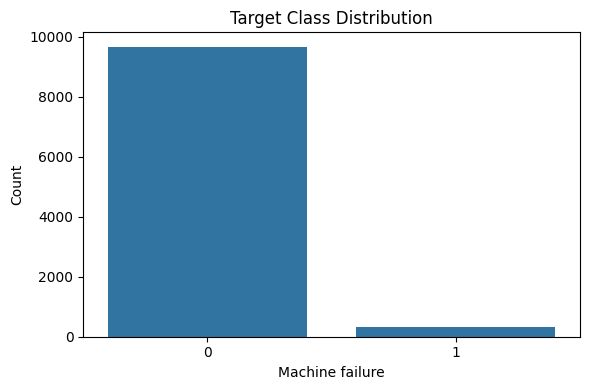

In [3]:
# Class balance
target = "machine_failure"
if target in df.columns:
    counts = df[target].value_counts().sort_index()
    plt.figure(figsize=(6,4))
    sns.barplot(x=counts.index.astype(str), y=counts.values)
    plt.xlabel("Machine failure")
    plt.ylabel("Count")
    plt.title("Target Class Distribution")
    plt.tight_layout()
    plt.show()
else:
    print("Target column not found.")

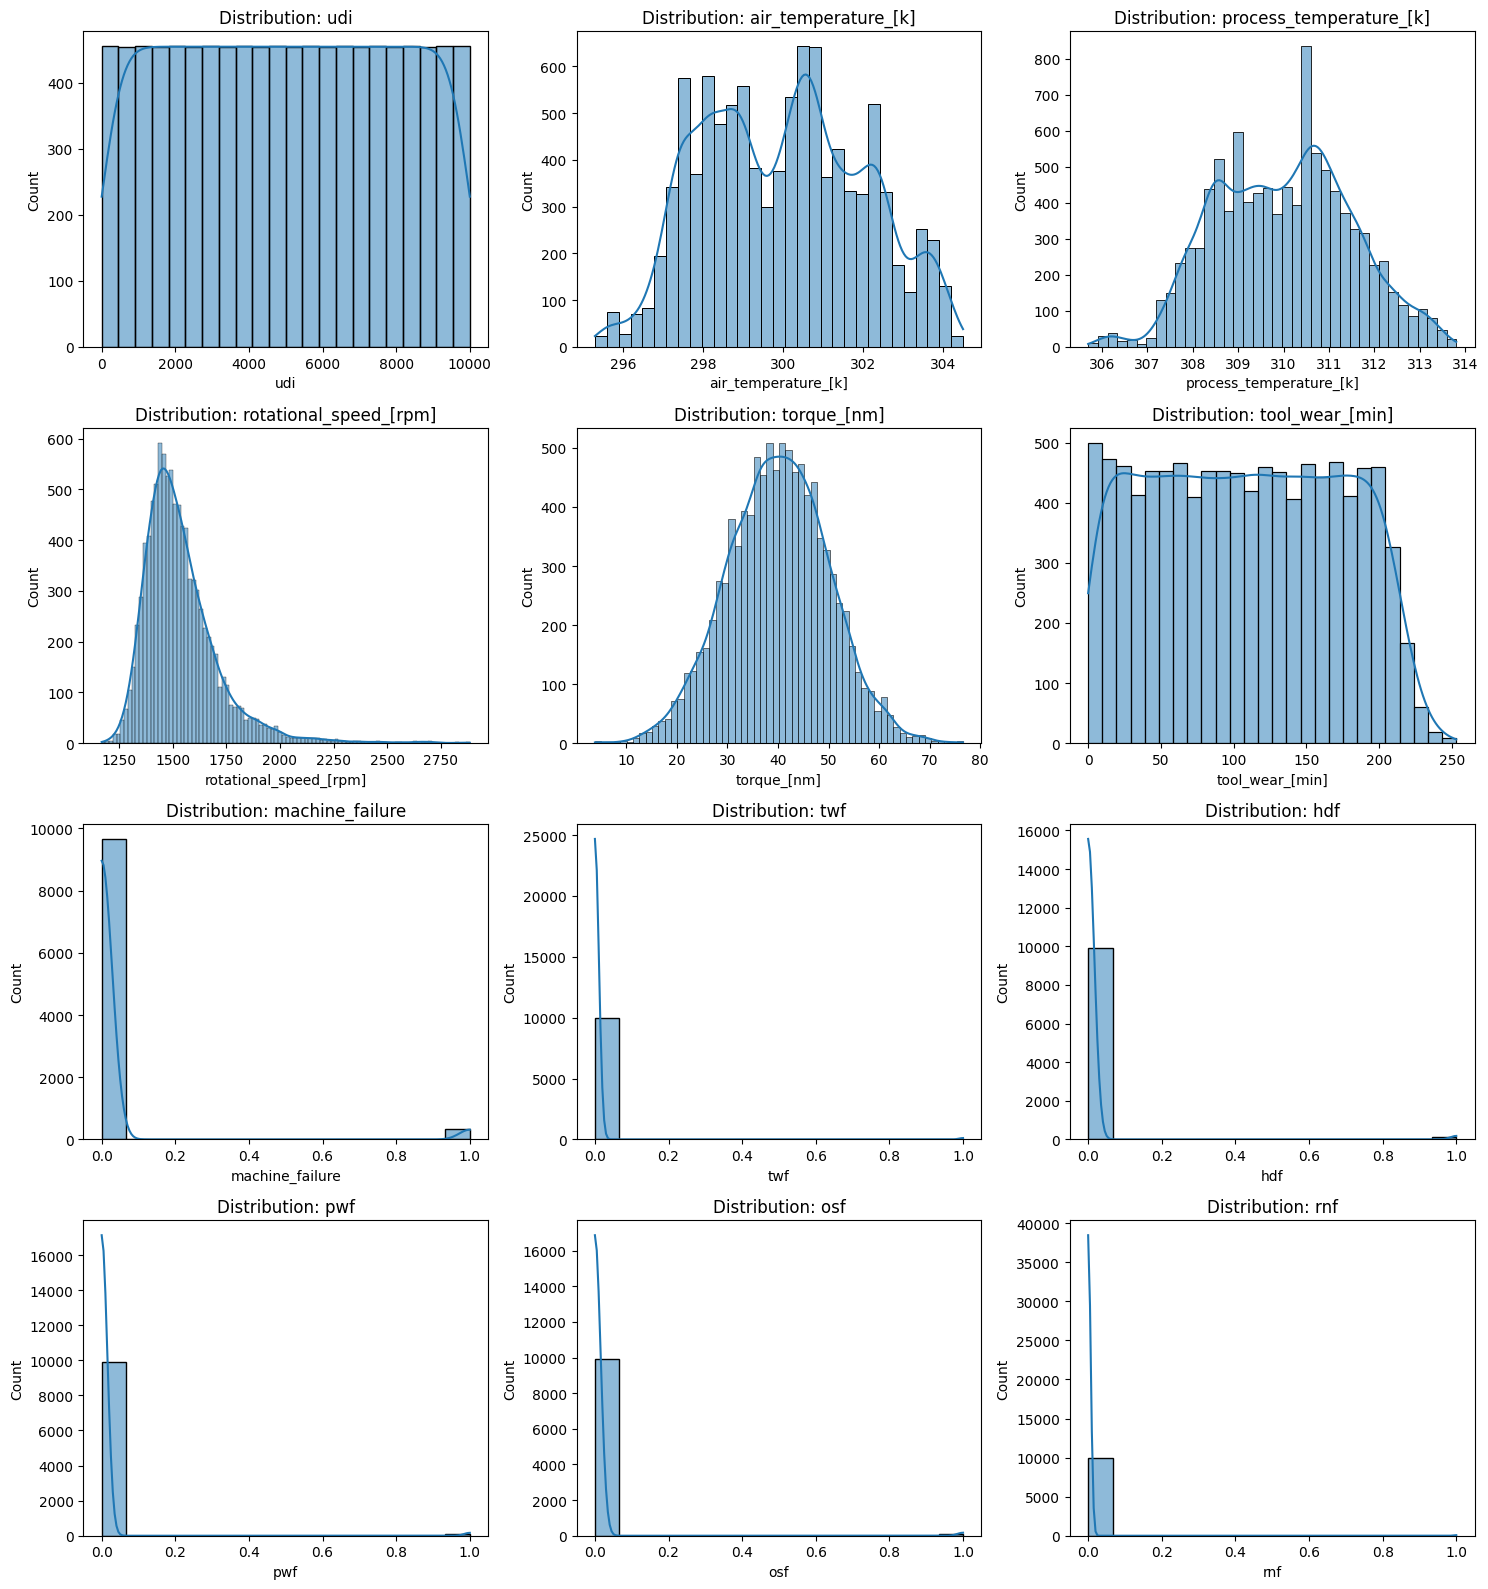

In [4]:
# Numerical sensor distributions
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if numeric_cols:
    n = len(numeric_cols)
    rows = int(np.ceil(n / 3))
    fig, axes = plt.subplots(rows, 3, figsize=(15, 4*rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=ax)
        ax.set_title(f"Distribution: {col}")
    for ax in axes[len(numeric_cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

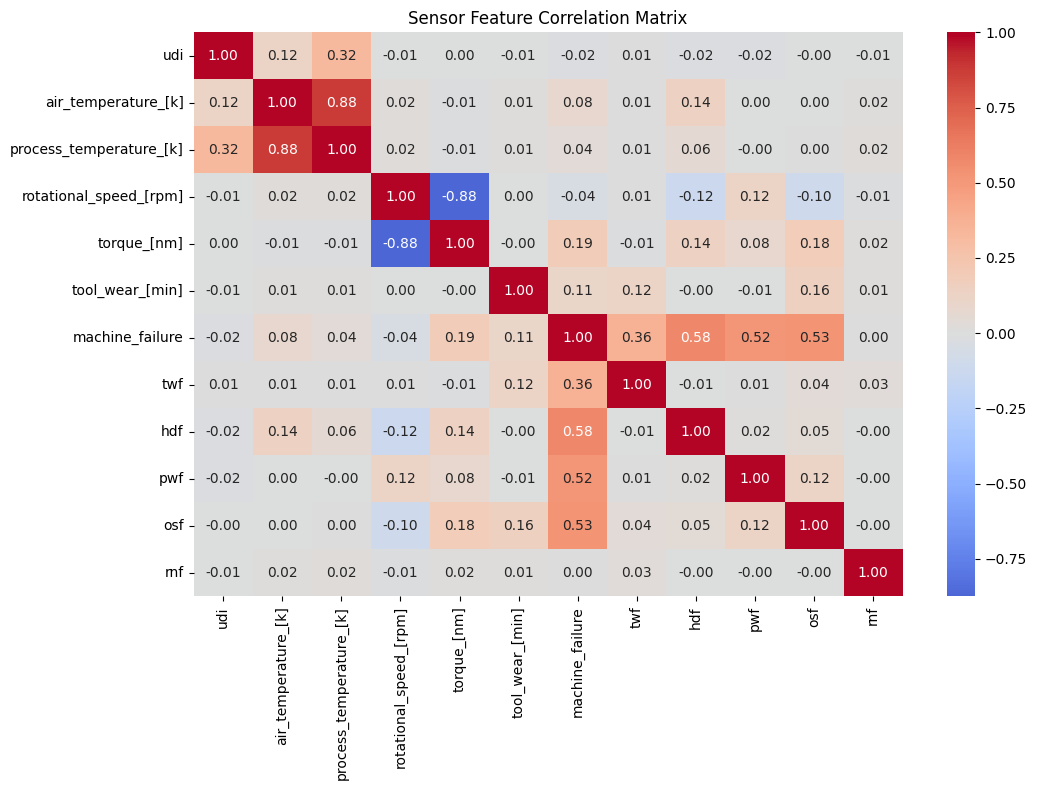

In [5]:
# Correlation matrix
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(11,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Sensor Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Save correlation matrix for the report
corr.to_csv(PROCESSED_DIR / "correlation_matrix.csv")